In [1]:
import numpy as np
import json 
import pandas as pd

In [2]:
from datetime import datetime, timezone

def get_time(timestamp):
    try:
        dt = datetime.fromtimestamp(timestamp/1000, tz=timezone.utc)
    except (OverflowError, OSError, ValueError) as e:
        print(f"Invalid timestamp {timestamp}: {e}")
        return None
    return dt

In [3]:
cpu_data = json.load(open("../data/ori_data/combined_results_cpu-util.json", "r", encoding='utf-8'))

In [4]:
cpu_data.keys()

dict_keys(['timestamps', 'metrics'])

In [29]:
type(cpu_data['timestamps']), type(cpu_data['metrics'])

(list, list)

In [4]:
cpu_df = pd.DataFrame(cpu_data)

In [7]:
cpu_df.head()

,timestamps,metrics
0,1753780560000,0.031258
1,1753780590000,0.030234
2,1753780620000,0.031014
3,1753780650000,0.031856
4,1753780680000,0.027486


In [10]:
cpu_df.shape

(86427, 2)

In [5]:
cpu_df['timestamps'] = cpu_df['timestamps'].apply(get_time)
cpu_df.set_index('timestamps', inplace=True)

Text(0, 0.5, 'CPU Util')

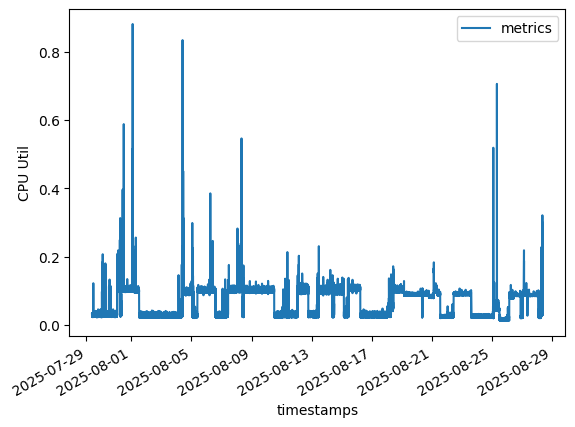

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt

ax = cpu_df.plot()
ax.set_ylabel("CPU Util")

Text(0, 0.5, 'CPU Util')

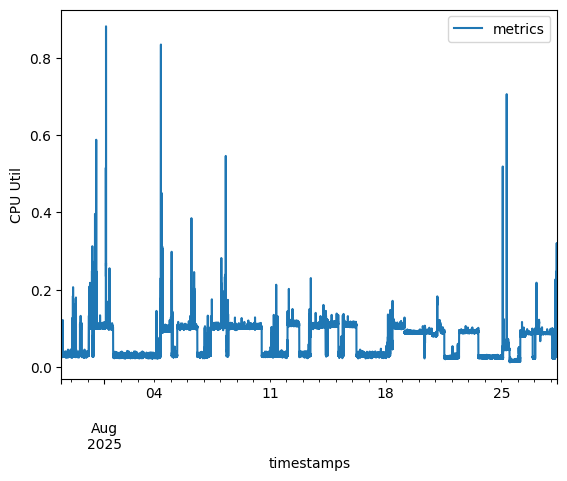

In [ ]:
# 1分钟采样，最大值聚合
ax = cpu_df.resample('1min').max().plot()
ax.set_ylabel("CPU Util")

In [23]:
cpu_df.head()

,metrics
timestamps,
2025-07-29 09:16:00+00:00,0.031258
2025-07-29 09:16:30+00:00,0.030234
2025-07-29 09:17:00+00:00,0.031014
2025-07-29 09:17:30+00:00,0.031856
2025-07-29 09:18:00+00:00,0.027486


In [33]:
cpu_df.tail()

,metrics
timestamps,
2025-08-28 09:14:30+00:00,0.098333
2025-08-28 09:15:00+00:00,0.098388
2025-08-28 09:15:30+00:00,0.094818
2025-08-28 09:16:00+00:00,0.101722
2025-08-28 09:16:30+00:00,0.103137


GPU数据

In [6]:
gpu_data = json.load(open("../data/ori_data/combined_results_gpu-util.json", "r", encoding='utf-8'))

In [26]:
gpu_data.keys()

dict_keys(['timestamps', 'metrics'])

In [27]:
type(gpu_data['timestamps']), type(gpu_data['metrics'])

(list, dict)

In [28]:
gpu_data['metrics'].keys()

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7'])

GPU数量有8个

In [7]:
gpu_df = pd.DataFrame({
    "timestamps":gpu_data['timestamps'],
    "0": gpu_data['metrics']['0'],
    "1": gpu_data['metrics']['1'],
    "2": gpu_data['metrics']['2'],
    "3": gpu_data['metrics']['3'],
    "4": gpu_data['metrics']['4'],
    "5": gpu_data['metrics']['5'],
    "6": gpu_data['metrics']['3'],
    "7": gpu_data['metrics']['7']
})
gpu_df['timestamps'] = gpu_df['timestamps'].apply(get_time)
gpu_df.set_index("timestamps", inplace=True)

In [32]:
gpu_df.head()

,0,1,2,3,4,5,6,7
timestamps,,,,,,,,
2025-07-29 09:29:30+00:00,0,0,0,0,0,0,0,0
2025-07-29 09:30:00+00:00,0,0,0,0,0,0,0,0
2025-07-29 09:30:30+00:00,0,0,0,0,0,0,0,0
2025-07-29 09:31:00+00:00,0,0,0,0,0,0,0,0
2025-07-29 09:31:30+00:00,0,0,0,0,0,0,0,0


In [34]:
gpu_df.tail()

,0,1,2,3,4,5,6,7
timestamps,,,,,,,,
2025-08-28 09:27:30+00:00,100,100,97,71,100,63,71,100
2025-08-28 09:28:00+00:00,61,76,96,100,100,100,100,100
2025-08-28 09:28:30+00:00,100,100,100,100,100,100,100,69
2025-08-28 09:29:00+00:00,100,100,100,100,55,100,100,84
2025-08-28 09:29:30+00:00,100,100,57,87,55,100,87,100


<Axes: xlabel='timestamps'>

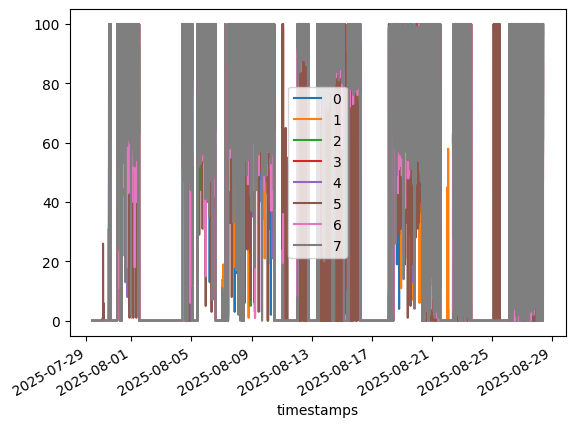

In [ ]:
gpu_df.plot()

<Axes: xlabel='timestamps'>

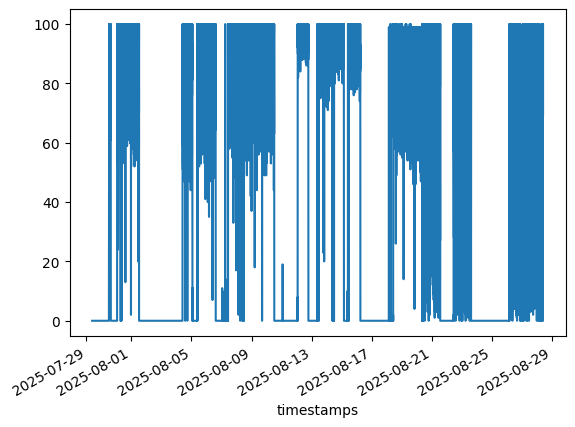

In [42]:
gpu_df['7'].plot()

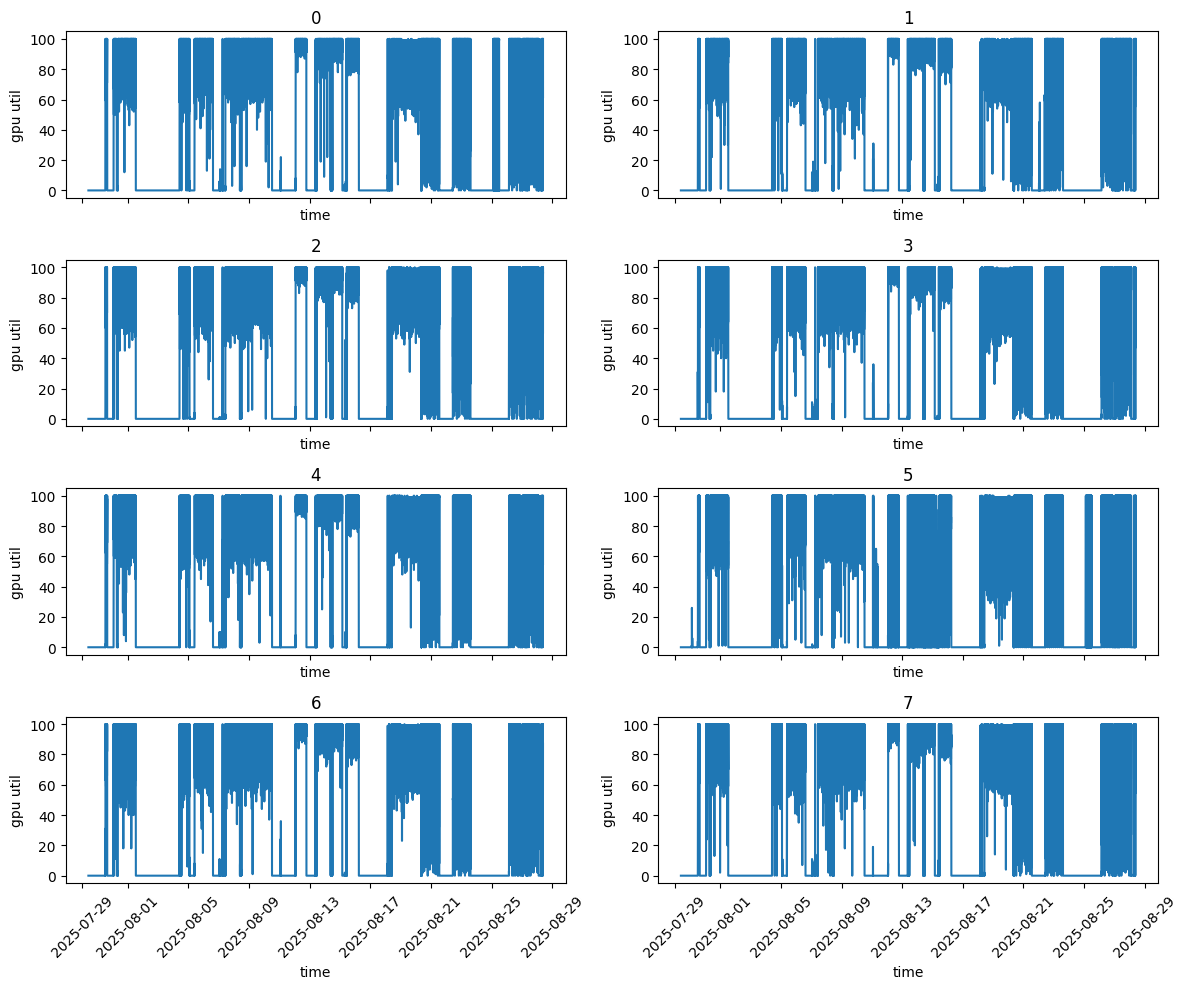

In [45]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()  # 将 4x2 的二维数组拉平，方便迭代

for i, col in enumerate(gpu_df.columns):
    axes[i].plot(gpu_df.index, gpu_df[col], label=col)
    axes[i].set_title(col)
    axes[i].set_xlabel("time")
    axes[i].set_ylabel("gpu util")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
mem_data = json.load(open("../data/ori_data/combined_results_mem-util.json", "r", encoding='utf-8'))

In [47]:
mem_data.keys()

dict_keys(['timestamps', 'metrics'])

In [48]:
type(mem_data['timestamps']), type(mem_data['metrics'])

(list, list)

In [9]:
mem_df = pd.DataFrame(mem_data)
mem_df['timestamps'] = mem_df['timestamps'].apply(get_time)
mem_df.set_index("timestamps", inplace=True)

In [51]:
mem_df.head()

,metrics
timestamps,
2025-07-29 09:19:00+00:00,136262684672
2025-07-29 09:19:30+00:00,136173043712
2025-07-29 09:20:00+00:00,136204398592
2025-07-29 09:20:30+00:00,136264888320
2025-07-29 09:21:00+00:00,136116158464


In [52]:
mem_df.tail()

,metrics
timestamps,
2025-08-28 09:17:30+00:00,201827815424
2025-08-28 09:18:00+00:00,201951444992
2025-08-28 09:18:30+00:00,202079948800
2025-08-28 09:19:00+00:00,202534207488
2025-08-28 09:19:30+00:00,202143997952


<Axes: xlabel='timestamps'>

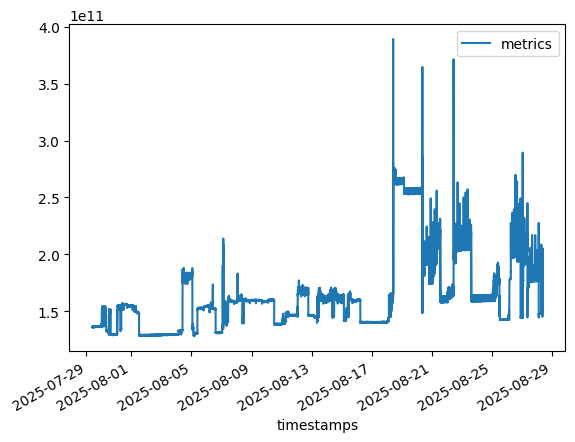

In [53]:
mem_df.plot()

In [10]:
# byte to MB
mem_df['metrics'] = mem_df.apply(lambda x: x / 1024 / 1024)

Text(0, 0.5, 'memory (MB)')

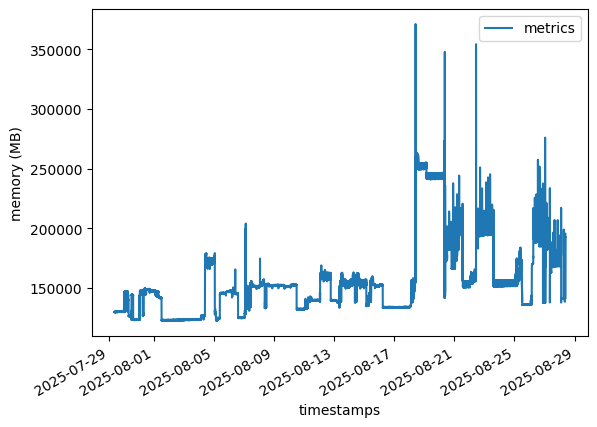

In [57]:
ax = mem_df.plot()
ax.set_ylabel("memory (MB)")

In [11]:
power_data = json.load(open("../data/ori_data/combined_results_power.json", "r", encoding='utf-8'))

In [59]:
power_data.keys()

dict_keys(['timestamps', 'metrics'])

In [60]:
type(power_data['metrics'])

list

In [12]:
power_df = pd.DataFrame(power_data)
power_df['timestamps'] = power_df['timestamps'].apply(get_time)
power_df.set_index("timestamps", inplace=True)

In [62]:
power_df.head()

,metrics
timestamps,
2025-07-29 09:31:30+00:00,1813
2025-07-29 09:32:00+00:00,1809
2025-07-29 09:32:30+00:00,1817
2025-07-29 09:33:00+00:00,1813
2025-07-29 09:33:30+00:00,1809


In [63]:
power_df.tail()

,metrics
timestamps,
2025-08-28 09:29:30+00:00,4307
2025-08-28 09:30:00+00:00,4601
2025-08-28 09:30:30+00:00,3386
2025-08-28 09:31:00+00:00,2670
2025-08-28 09:31:30+00:00,4322


Text(0, 0.5, 'Power (watt)')

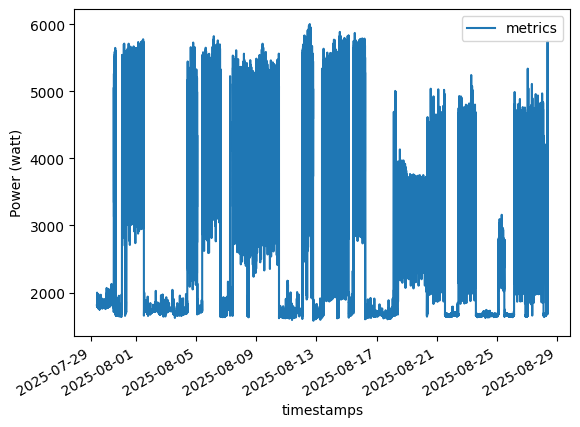

In [64]:
ax = power_df.plot()
ax.set_ylabel("Power (watt)")

In [14]:
temp_data = json.load(open("../data/ori_data/combined_results_temperature.json", "r", encoding='utf-8'))

In [68]:
temp_data['metrics'].keys()

dict_keys(['Inlet_Temp', 'Outlet_Temp1', 'Outlet_Temp2'])

In [15]:
temp_df = pd.DataFrame({
    "timestamps": temp_data['timestamps'],
    "Inlet_Temp": temp_data['metrics']['Inlet_Temp'],
    "Outlet_Temp1": temp_data['metrics']['Outlet_Temp1'],
    "Outlet_Temp2": temp_data['metrics']['Outlet_Temp2']
})
temp_df['timestamps'] = temp_df['timestamps'].apply(get_time)
temp_df.set_index("timestamps", inplace=True)

In [71]:
temp_df.head()

,Inlet_Temp,Outlet_Temp1,Outlet_Temp2
timestamps,,,
2025-07-29 09:42:00+00:00,29,43,34
2025-07-29 09:42:30+00:00,29,44,33
2025-07-29 09:43:00+00:00,29,44,33
2025-07-29 09:43:30+00:00,28,44,33
2025-07-29 09:44:00+00:00,28,44,33


In [72]:
temp_df.tail()

,Inlet_Temp,Outlet_Temp1,Outlet_Temp2
timestamps,,,
2025-08-28 09:40:00+00:00,27,41,30
2025-08-28 09:40:30+00:00,27,41,30
2025-08-28 09:41:00+00:00,27,41,30
2025-08-28 09:41:30+00:00,27,41,30
2025-08-28 09:42:00+00:00,27,41,30


<Axes: xlabel='timestamps'>

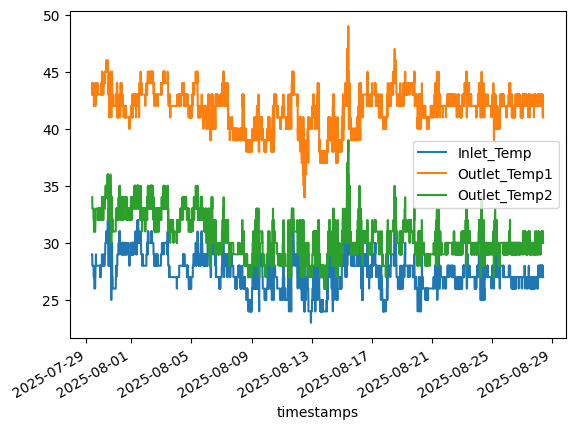

In [74]:
temp_df.plot()

merge multi-source data

In [16]:
start = "2025-07-29 09:42:00"
end = "2025-08-28 09:16:30"

time_index = pd.date_range(start=start, end=end, freq="30s")

In [17]:
temp_df.index = pd.to_datetime(temp_df.index)
temp_df.index = temp_df.index.tz_localize(None)
cpu_df.index = pd.to_datetime(cpu_df.index)
cpu_df.index = cpu_df.index.tz_localize(None)
mem_df.index = pd.to_datetime(mem_df.index)
mem_df.index = mem_df.index.tz_localize(None)
gpu_df.index = pd.to_datetime(gpu_df.index)
gpu_df.index = gpu_df.index.tz_localize(None)
power_df.index = pd.to_datetime(power_df.index)
power_df.index = power_df.index.tz_localize(None)

In [18]:
# duplicate index
# cpu_df[cpu_df.index.duplicated(keep=False)]

In [ ]:
# cpu_df = cpu_df.groupby(cpu_df.index).max()

In [ ]:
# cpu_df[cpu_df.index.duplicated(keep=False)]

,metrics
timestamps,


In [19]:
# delete duplicated index
gpu_df = gpu_df.groupby(gpu_df.index).max()
mem_df = mem_df.groupby(mem_df.index).max()
temp_df = temp_df.groupby(temp_df.index).max()
power_df = power_df.groupby(power_df.index).max()

In [21]:
cpu_df = cpu_df.groupby(cpu_df.index).max()

In [22]:
temp = temp_df.reindex(time_index)
cpu = cpu_df.reindex(time_index)
gpu = gpu_df.reindex(time_index)
mem = mem_df.reindex(time_index)
power = power_df.reindex(time_index)

In [24]:
combined_df = pd.concat([cpu, gpu, mem, power, temp], axis=1)

In [25]:
combined_df.columns = ['cpu_util', 'gpu0_util', 'gpu1_util', 'gpu2_util', 
                      'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util',
                      'memory', 'power', 'Inlet_Temp', 'Outlet_Temp1', 'Outlet_Temp2']

In [109]:
combined_df.shape

(86350, 14)

In [110]:
combined_df.head()

,cpu_util,gpu0_util,gpu1_util,gpu2_util,gpu3_util,gpu4_util,gpu5_util,gpu6_util,gpu7_util,memory,power,Inlet_Temp,Outlet_Temp1,Outlet_Temp2
2025-07-29 09:42:00,0.030275,0,0,0,0,0,0,0,0,129814.046875,1809,29,43,34
2025-07-29 09:42:30,0.028490,0,0,0,0,0,0,0,0,129840.031250,1810,29,44,33
2025-07-29 09:43:00,0.025050,0,0,0,0,0,0,0,0,129625.785156,1810,29,44,33
2025-07-29 09:43:30,0.030722,0,0,0,0,0,0,0,0,129662.945312,1999,28,44,33
2025-07-29 09:44:00,0.031791,0,0,0,0,0,0,0,0,129819.125000,1813,28,44,33


In [26]:
combined_df.shape

(86350, 14)

In [27]:
combined_df.to_csv("../data/processed_data/datacenter.csv", index_label="timestamp")